In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Exercise 1
# Define Problem study 
print("The study aims to analyze and predict car prices (MSRP) based on vehicle characteristics such as engine power, fuel type, vehicle size, fuel efficiency, and brand.")


The study aims to analyze and predict car prices (MSRP) based on vehicle characteristics such as engine power, fuel type, vehicle size, fuel efficiency, and brand.


In [6]:
# Exercise 2
# what type of your problem study?
print("Continuous regression problem, as the target variable (MSRP) is a continuous numerical value.")

Continuous regression problem, as the target variable (MSRP) is a continuous numerical value.


In [7]:
# Exercise 3
# Upload data
# Import dataset
df = pd.read_csv("archive/data.csv")

# Introduce dataset
df.head()


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [8]:
# EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [9]:
df.shape

(11914, 16)

In [10]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [11]:
df.describe(include='object')

,Make,Model,Engine Fuel Type,Transmission Type,Driven_Wheels,Market Category,Vehicle Size,Vehicle Style
count,11914,11914,11911,11914,11914,8172,11914,11914
unique,48,915,10,5,4,71,3,16
top,Chevrolet,Silverado 1500,regular unleaded,AUTOMATIC,front wheel drive,Crossover,Compact,Sedan
freq,1123,156,7172,8266,4787,1110,4764,3048


In [12]:
(df.isnull().sum() / len(df) * 100) 

Make                  0.000000
Model                 0.000000
Year                  0.000000
Engine Fuel Type      0.025180
Engine HP             0.579151
Engine Cylinders      0.251805
Transmission Type     0.000000
Driven_Wheels         0.000000
Number of Doors       0.050361
Market Category      31.408427
Vehicle Size          0.000000
Vehicle Style         0.000000
highway MPG           0.000000
city mpg              0.000000
Popularity            0.000000
MSRP                  0.000000
dtype: float64

In [13]:
numerical_columns = df.select_dtypes(include=[np.number]).columns
for col in numerical_columns:
    skew = df[col].skew()
    print(f"Skewness of {col}: {skew:.2f}")

Skewness of Year: -1.22
Skewness of Engine HP: 1.29
Skewness of Engine Cylinders: 0.96
Skewness of Number of Doors: -0.97
Skewness of highway MPG: 7.57
Skewness of city mpg: 7.11
Skewness of Popularity: 1.65
Skewness of MSRP: 11.77


In [14]:
df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])

In [15]:
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())

In [16]:
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median()) 

In [17]:
# Exercise 4
# Data cleansing
df.dropna(inplace=True)
(df.isnull().sum() / len(df) * 100) 

Make                 0.0
Model                0.0
Year                 0.0
Engine Fuel Type     0.0
Engine HP            0.0
Engine Cylinders     0.0
Transmission Type    0.0
Driven_Wheels        0.0
Number of Doors      0.0
Market Category      0.0
Vehicle Size         0.0
Vehicle Style        0.0
highway MPG          0.0
city mpg             0.0
Popularity           0.0
MSRP                 0.0
dtype: float64

In [18]:
df.duplicated().sum()

np.int64(349)

In [19]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

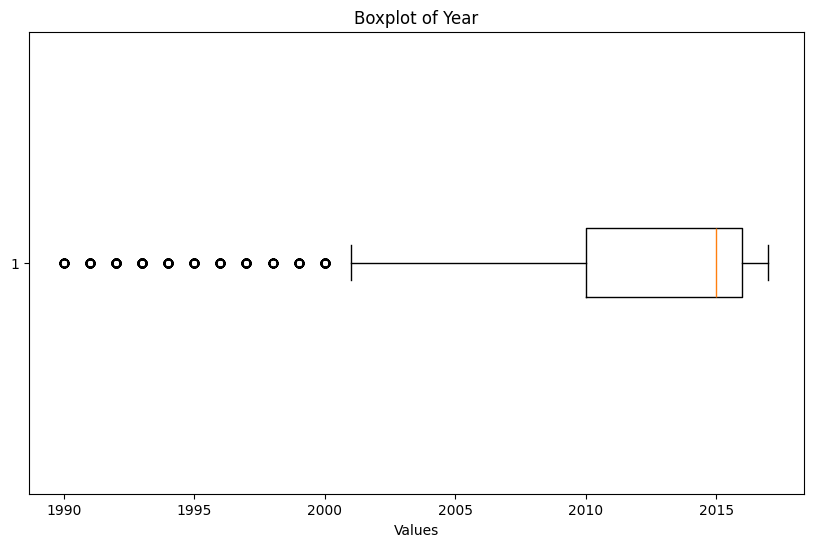

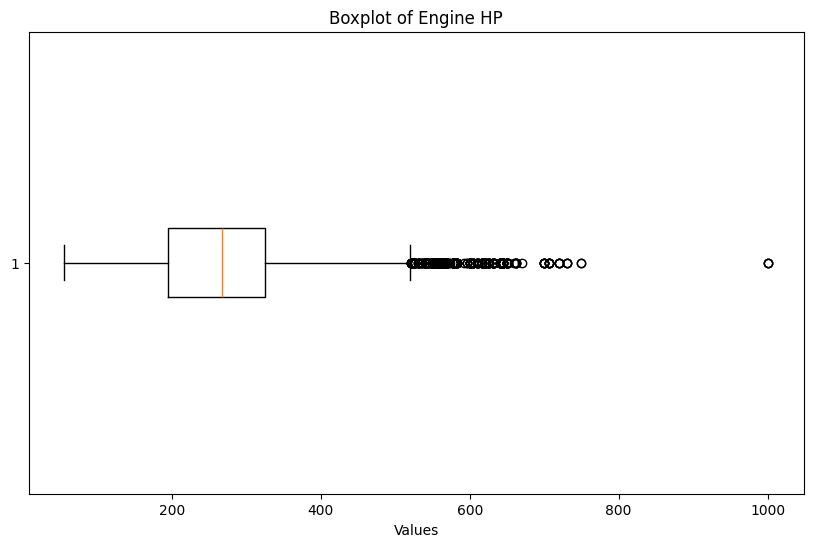

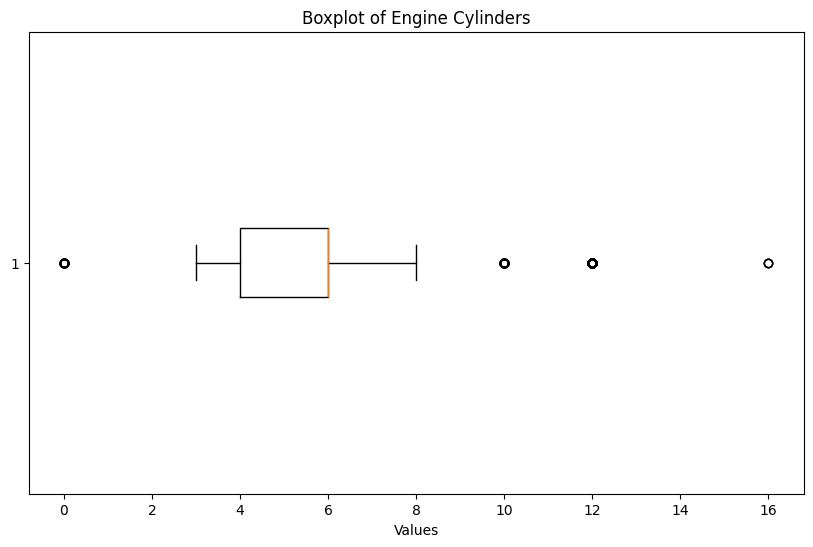

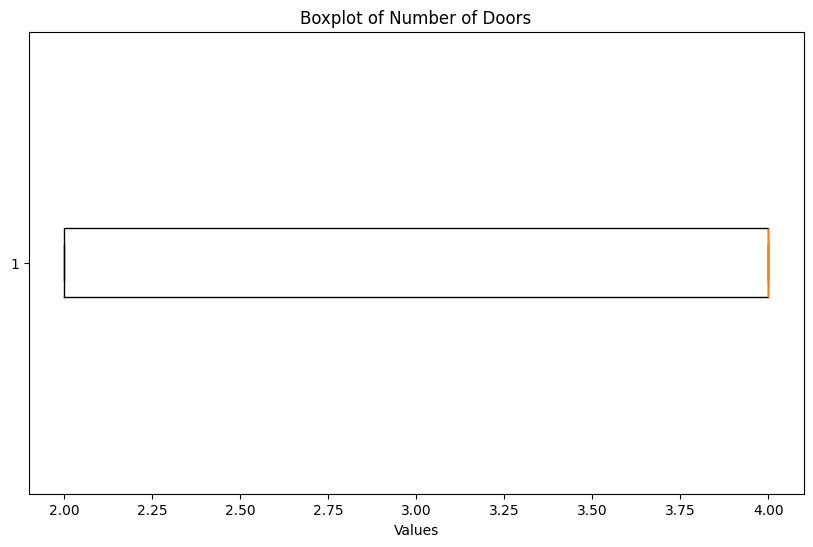

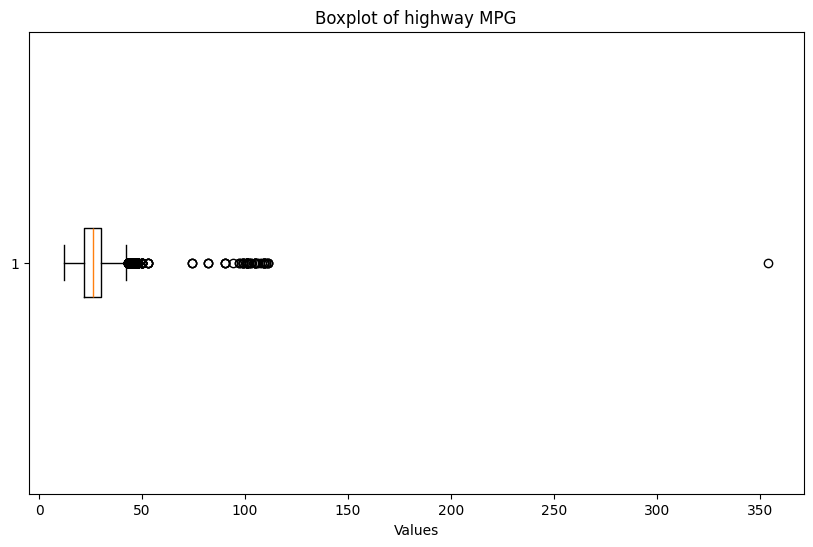

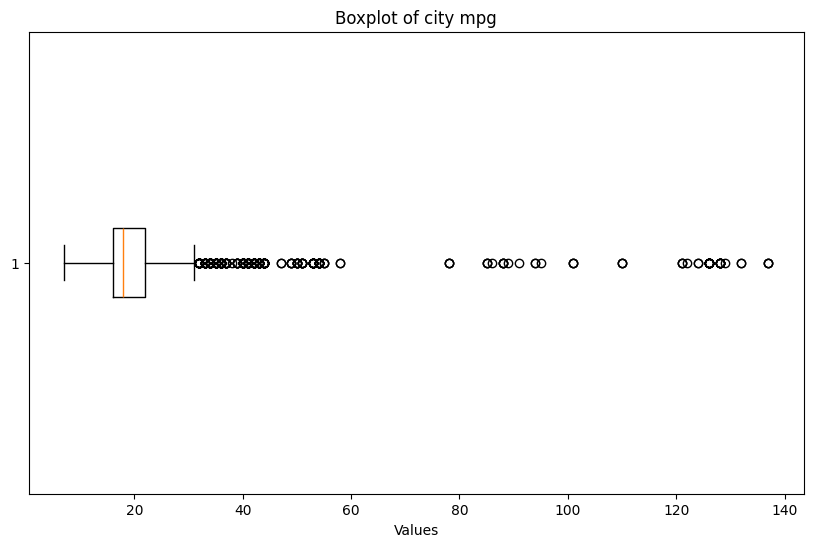

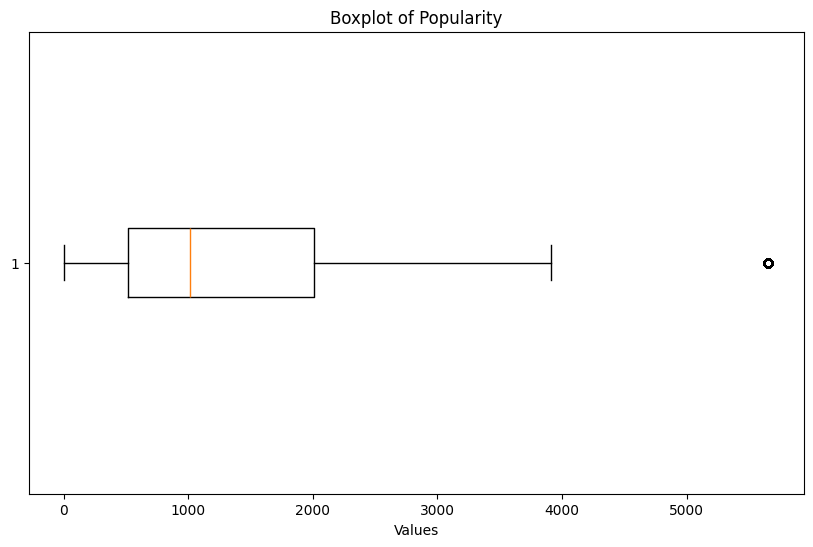

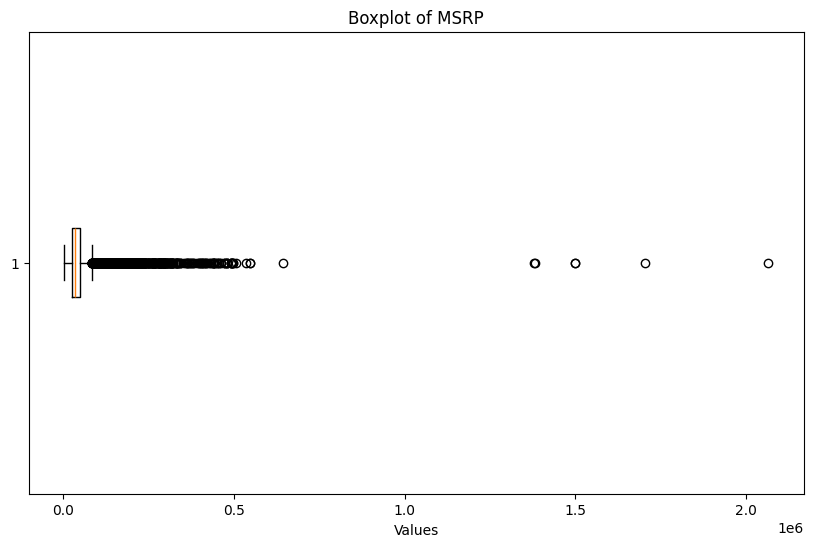

In [20]:
# Missing value, outlier, ....
# boxplot
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel("Values")
    plt.show()

In [21]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).sum()
print("Number of outliers in each numeric column:")
print(outliers)

Number of outliers in each numeric column:
Year                591
Engine HP           387
Engine Cylinders    341
Number of Doors       0
highway MPG         172
city mpg            288
Popularity          492
MSRP                806
dtype: int64


In [22]:
df.shape

(7817, 16)

In [23]:
# drop outlier
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [24]:

categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:")
print(categorical_cols)
value_counts = {}
for col in categorical_cols:
    value_counts[col] = df[col].value_counts()
print("Value counts for each categorical column:")

print(value_counts)

Categorical columns:
Index(['Make', 'Model', 'Engine Fuel Type', 'Transmission Type',
       'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style'],
      dtype='object')
Value counts for each categorical column:
{'Make': Make
Chevrolet        576
Volkswagen       380
Cadillac         315
Infiniti         311
Nissan           268
GMC              266
Dodge            242
Audi             239
BMW              223
Mazda            220
Toyota           211
Honda            204
Acura            203
Volvo            187
Subaru           180
Hyundai          179
Mercedes-Benz    169
Lexus            155
Lincoln          143
Buick            123
Chrysler         102
Kia              101
Suzuki            94
Land Rover        89
Mitsubishi        84
Saab              78
Pontiac           72
Scion             44
FIAT              38
Porsche           36
Lotus             23
HUMMER            17
Maserati           9
Alfa Romeo         5
Oldsmobile         3
Genesis            3
Ply

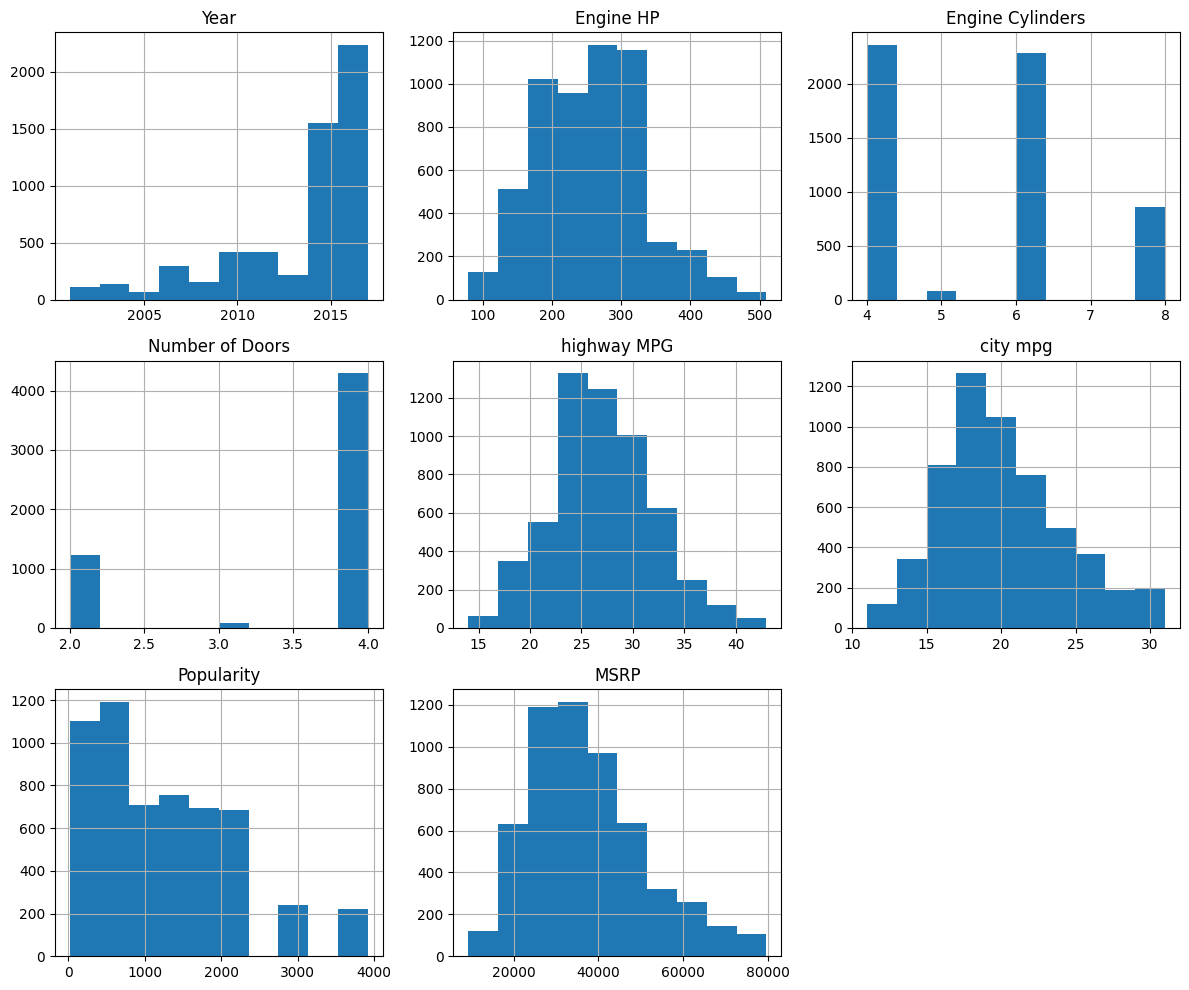

In [25]:
# Exercise 5
# Data visualization 
# Discribuation, correlation, Comparing,....
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


In [26]:
import seaborn as sns

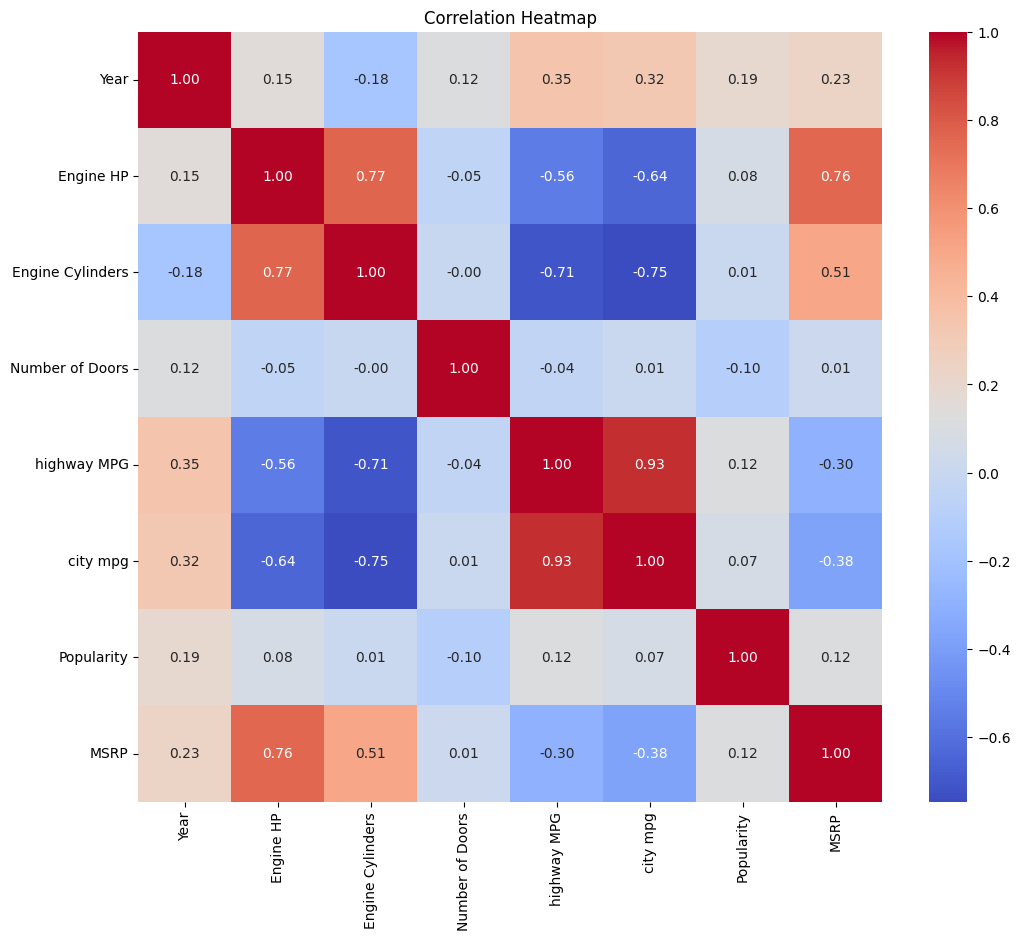

In [27]:
# plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

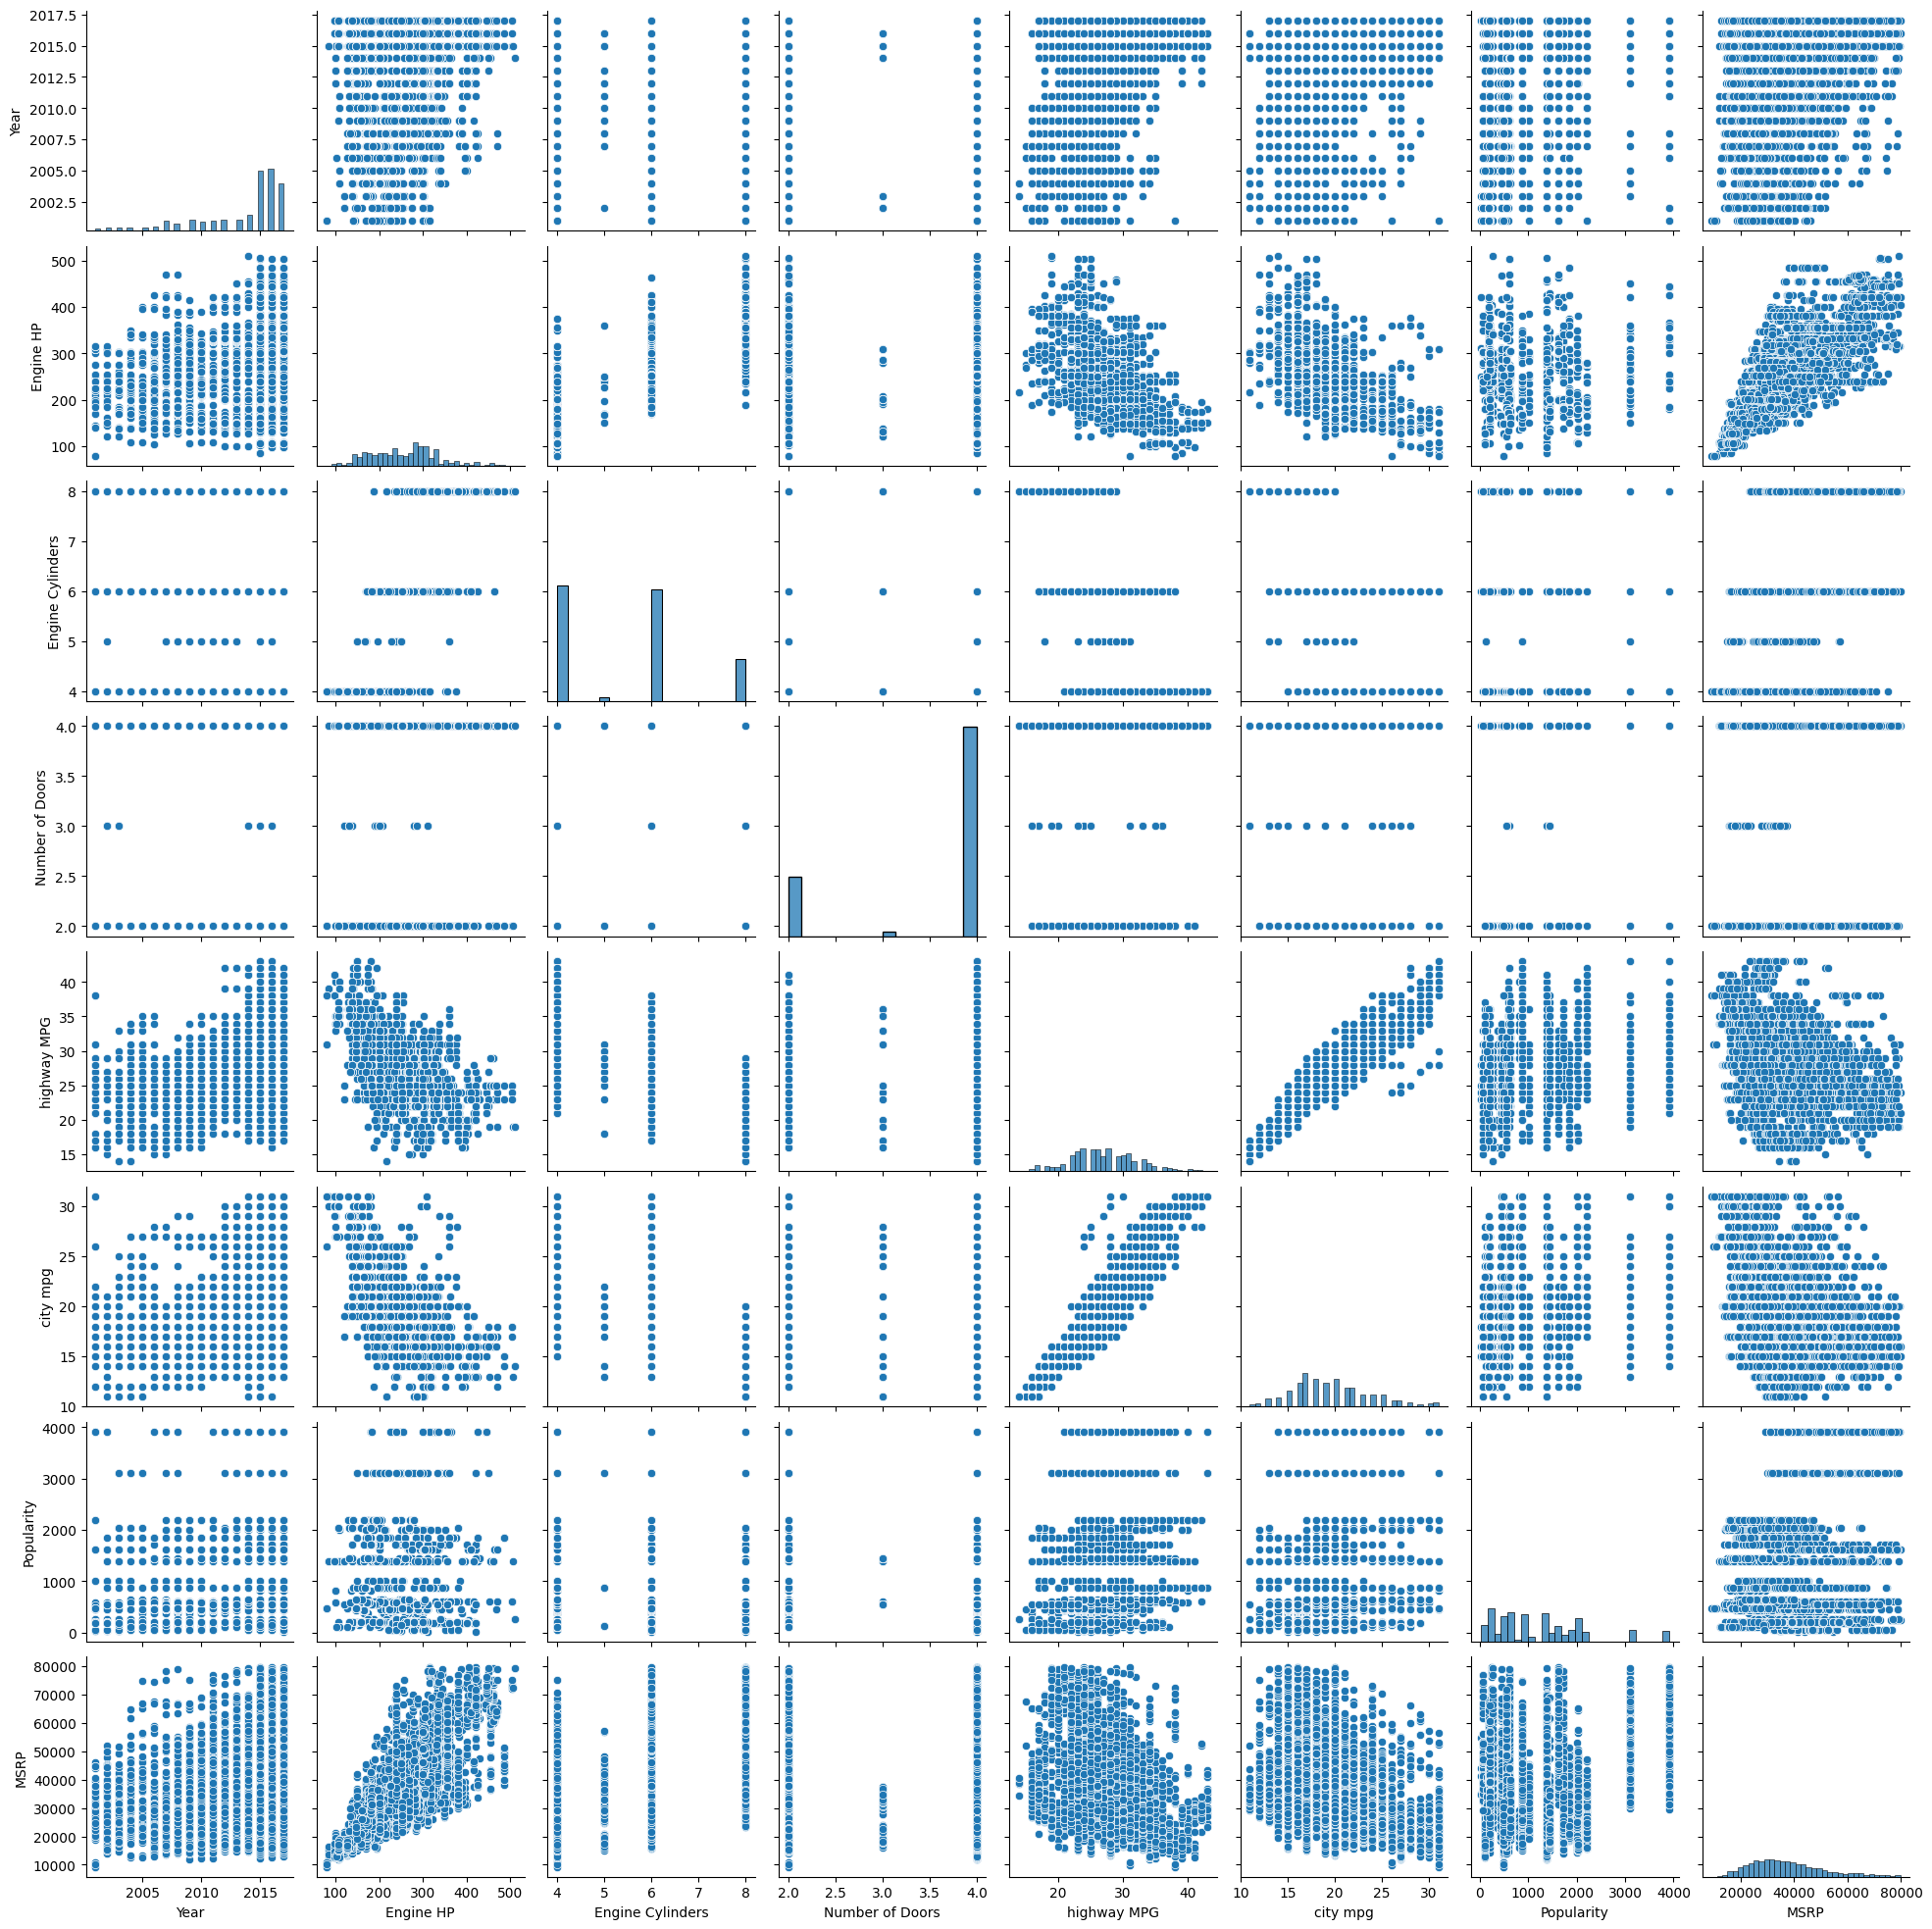

In [28]:
sns.pairplot(df[numeric_cols])
plt.show()

   Make  Model  Engine Fuel Type  ...  Market Category  Vehicle Size  Vehicle Style
0     3      1                 6  ...               25             0              8
1     3      0                 6  ...               50             0              6
2     3      0                 6  ...               47             0              8
3     3      0                 6  ...               50             0              8
4     3      0                 6  ...               46             0              6

[5 rows x 8 columns]


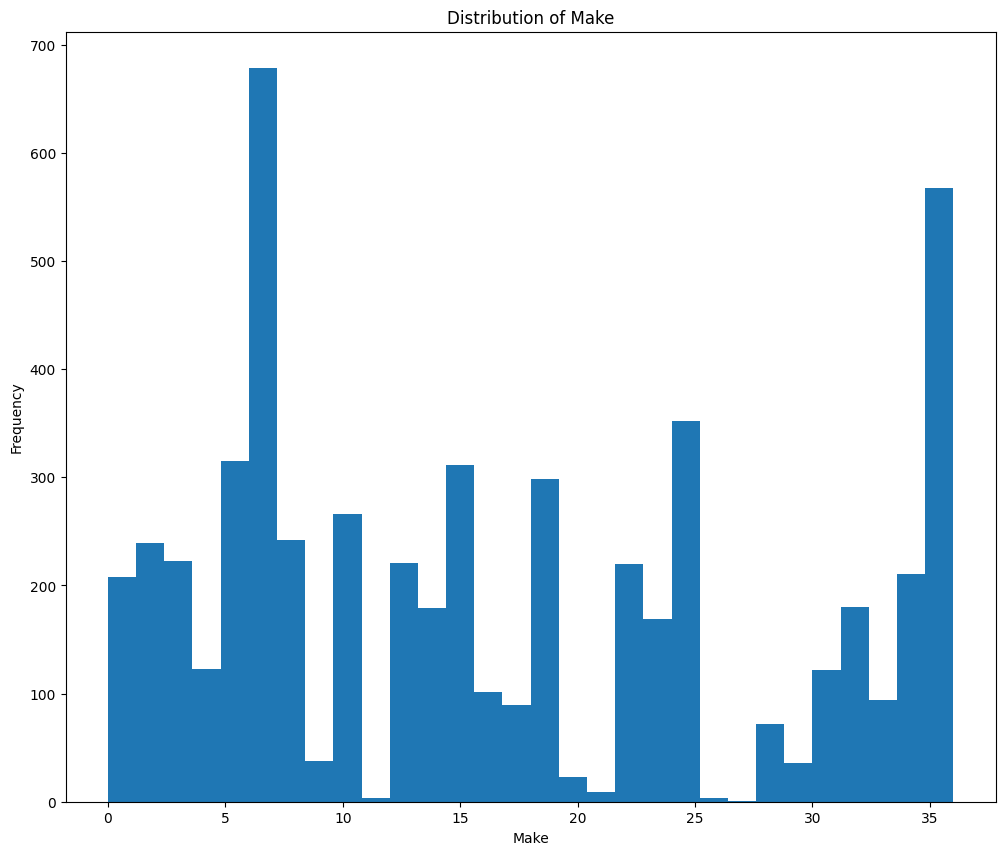

In [29]:
# Exercise 6
# Encoding
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes
print(df[categorical_cols].head())

plt.figure(figsize=(12, 10))
plt.hist(df[categorical_cols[0]], bins=30)
plt.xlabel(categorical_cols[0])
plt.ylabel("Frequency")
plt.title("Distribution of {}".format(categorical_cols[0]))
plt.show()
# Scaling (If need)
# Feature selection (If need)




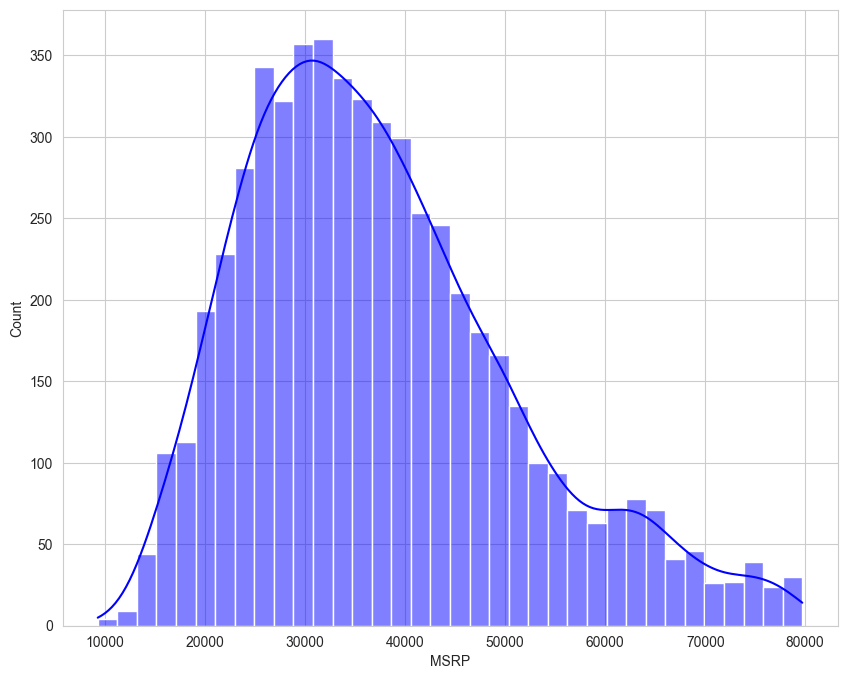

In [30]:
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.histplot(data=df, x='MSRP', kde=True, color='blue')
plt.show()

In [31]:
# Exercise 6
# Encoding 
# Scaling (If need)
# Feature selection (If need)
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes
    
print(df[categorical_cols].head())

   Make  Model  Engine Fuel Type  ...  Market Category  Vehicle Size  Vehicle Style
0     3      1                 6  ...               25             0              8
1     3      0                 6  ...               50             0              6
2     3      0                 6  ...               47             0              8
3     3      0                 6  ...               50             0              8
4     3      0                 6  ...               46             0              6

[5 rows x 8 columns]


In [32]:
import pickle
with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump(df, f)

In [ ]:
X = df.drop('MSRP', axis=1)
y = df['MSRP']

   Make  Model  Year  ...  highway MPG  city mpg  Popularity
0     3      1  2011  ...           26        19        3916
1     3      0  2011  ...           28        19        3916
2     3      0  2011  ...           28        20        3916
3     3      0  2011  ...           28        18        3916
4     3      0  2011  ...           28        18        3916

[5 rows x 15 columns]


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

In [38]:
len(X_train), len(X_val), len(X_test)

(3915, 839, 839)

In [40]:
# Exercise 7 
# Splite data for taining and testing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
# Exercisse 8
# Model training 

y_train_pred = model.predict(X_train)

train_mse  = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2   = r2_score(y_train, y_train_pred)

print(f"Train MSE : {train_mse:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train R²  : {train_r2:.4f}")


Train MSE : 65577295.52
Train RMSE: 8097.98
Train R²  : 0.6480


In [42]:
# Exercise 9
# Model evaluation 
y_val_pred = model.predict(X_val)

# Metrics
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

print(f"Validation MSE: {val_mse:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")
print(f"Validation R2: {val_r2:.2f}")



Validation MSE: 68301756.21
Validation RMSE: 8264.49
Validation R2: 0.61


In [44]:
# Model testing
y_test_pred = model.predict(X_test)
test_mse  = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2   = r2_score(y_test, y_test_pred)

print(f"Test MSE : {test_mse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²  : {test_r2:.4f}")

Test MSE : 69699500.39
Test RMSE: 8348.62
Test R²  : 0.6453


In [45]:
# --- Summary comparison ---
print("\n--- Performance Summary ---")
print(f"{'Split':<10} {'MSE':>15} {'RMSE':>12} {'R²':>10}")
print("-" * 50)
print(f"{'Train':<10} {train_mse:>15.2f} {train_rmse:>12.2f} {train_r2:>10.4f}")
print(f"{'Val':<10} {val_mse:>15.2f} {val_rmse:>12.2f} {val_r2:>10.4f}")
print(f"{'Test':<10} {test_mse:>15.2f} {test_rmse:>12.2f} {test_r2:>10.4f}")


--- Performance Summary ---
Split                  MSE         RMSE         R²
--------------------------------------------------
Train          65577295.52      8097.98     0.6480
Val            68301756.21      8264.49     0.6056
Test           69699500.39      8348.62     0.6453


<Axes: xlabel='MSRP', ylabel='Count'>

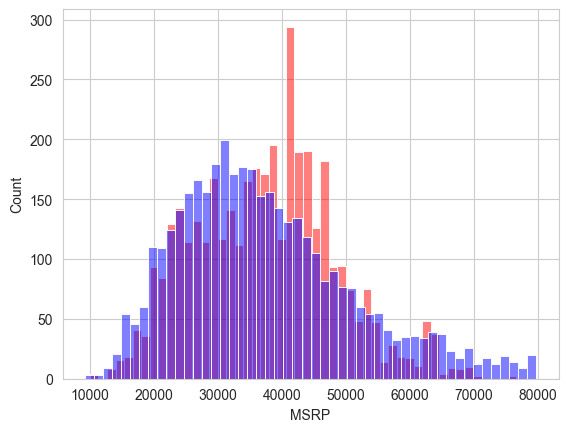

In [46]:
sns.histplot(y_train_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

<Axes: xlabel='MSRP', ylabel='Count'>

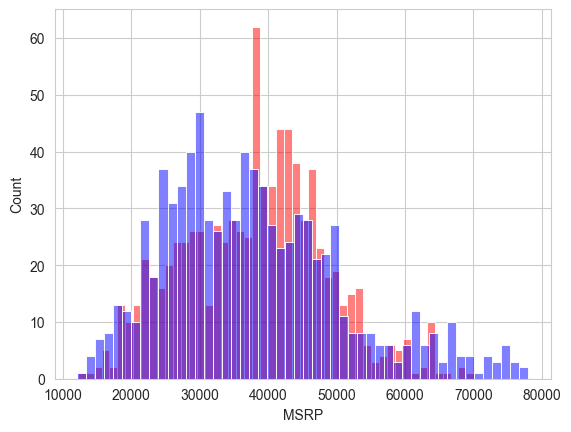

In [48]:
sns.histplot(y_val_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

<Axes: xlabel='MSRP', ylabel='Count'>

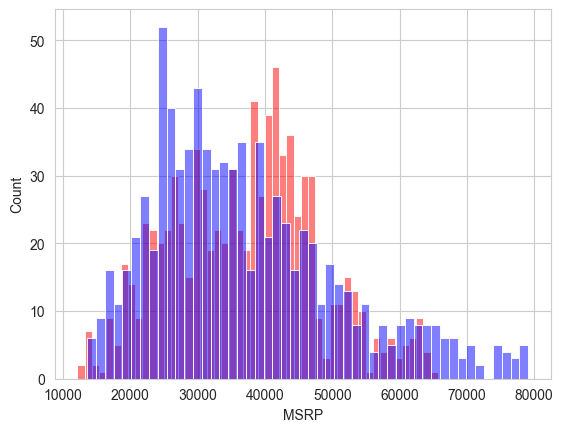

In [49]:
sns.histplot(y_test_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_test, color='blue', alpha=0.5, bins=50)